In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

I0000 00:00:1790221381.762555    8318 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790221381.764259    8318 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
keras.utils.set_random_seed(42)

In [4]:
df = pd.read_csv("data/heart.csv")

In [5]:
df.shape

(303, 14)

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [7]:
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

In [8]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerics = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

In [9]:
oneHotDf = pd.get_dummies(df, columns=categorical_variables)

In [10]:
oneHotDf.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [11]:
testDf = oneHotDf.sample(frac=0.2, random_state=42)
trainDf = oneHotDf.drop(testDf.index)

In [12]:
print(testDf.shape)
print(trainDf.shape)

(61, 30)
(242, 30)


In [13]:
# Normalize
mean = trainDf[numerics].mean()
sd = trainDf[numerics].std()

print(mean, sd, "\n")

trainDf[numerics] = (trainDf[numerics] - mean)/sd
testDf[numerics] = (testDf[numerics] - mean)/sd

age          54.268595
trestbps    131.995868
chol        246.512397
thalach     149.805785
oldpeak       1.032645
slope         1.590909
dtype: float64 age          9.059861
trestbps    18.012789
chol        48.485377
thalach     23.132298
oldpeak      1.169729
slope        0.632783
dtype: float64 



In [14]:
trainDf.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [15]:
train = trainDf.to_numpy()
test = testDf.to_numpy()

In [16]:
trainX = np.delete(train, 6, axis=1)
testX = np.delete(test, 6, axis=1)
trainY = train[:, 6]
testY = test[:, 6]

In [17]:
trainX.shape

(242, 29)

In [ ]:
npdType = np.float64

In [85]:
numCol = trainX.shape[1]
input = keras.Input(shape=(numCol,))
h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(input, output)

In [86]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

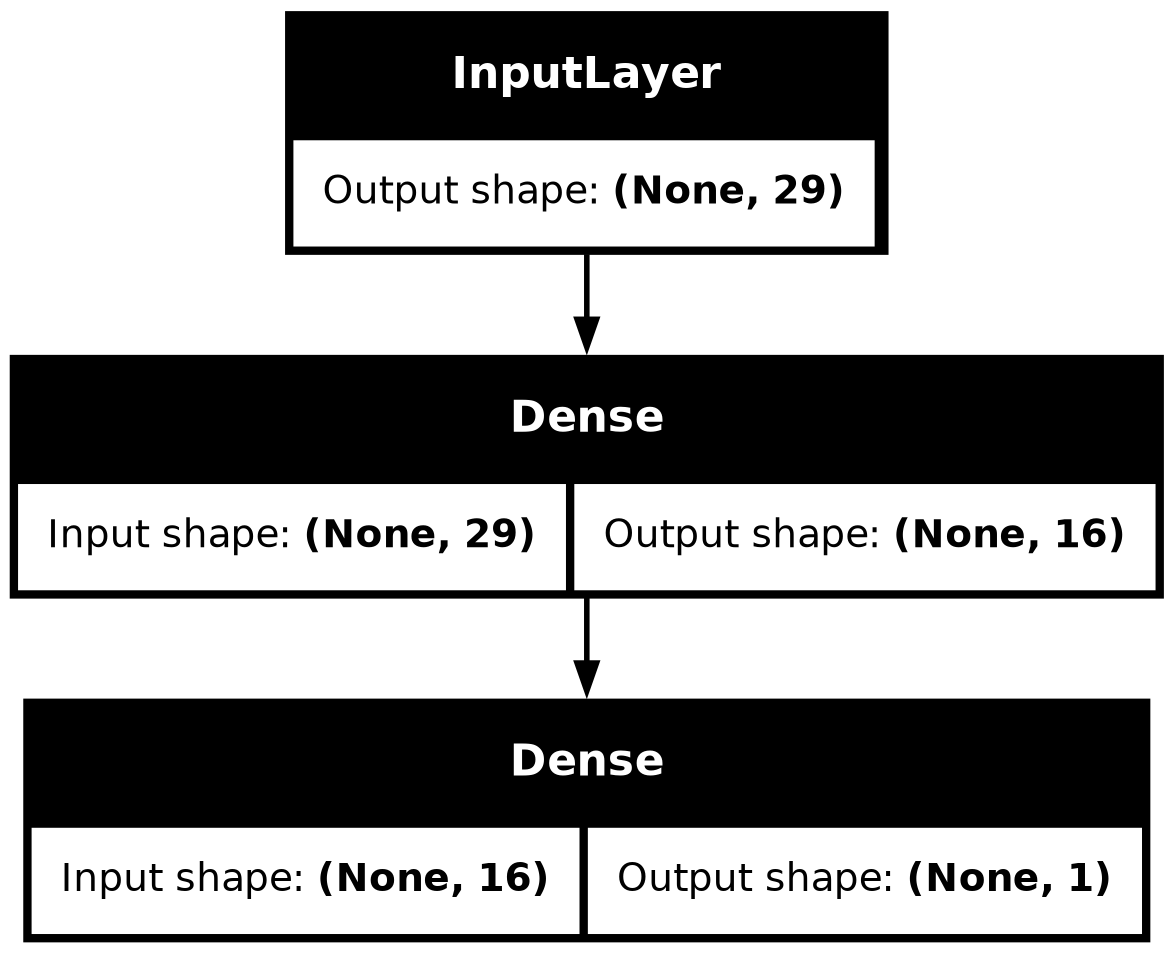

In [87]:
keras.utils.plot_model(model, show_shapes=True)

In [88]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [89]:
history = model.fit(np.asarray(trainX, dtype=npdType),
                    np.asarray(trainY, dtype=npdType),
                    epochs=300,
                    batch_size=32,
                    verbose=1,
                    validation_split=0.2)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3005 - loss: 0.8345 - val_accuracy: 0.3061 - val_loss: 0.8065
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3679 - loss: 0.7847 - val_accuracy: 0.3878 - val_loss: 0.7667
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4456 - loss: 0.7415 - val_accuracy: 0.4082 - val_loss: 0.7313
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5130 - loss: 0.7023 - val_accuracy: 0.5306 - val_loss: 0.7004
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5855 - loss: 0.6664 - val_accuracy: 0.6122 - val_loss: 0.6731
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6580 - loss: 0.6335 - val_accuracy: 0.6939 - val_loss: 0.6491
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7150 - loss: 0.6032 - val_accuracy: 0.7347 - val_loss: 0.6278
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7513 - loss: 0.5756 - val_accuracy: 0.7143 - val_loss:

In [90]:
historyDict = history.history
historyDict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

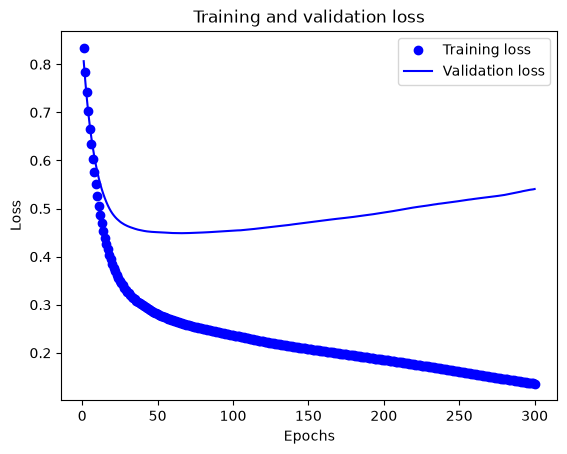

In [91]:
loss = historyDict["loss"]
valLoss = historyDict["val_loss"]
epochs = range(1, len(valLoss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, valLoss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

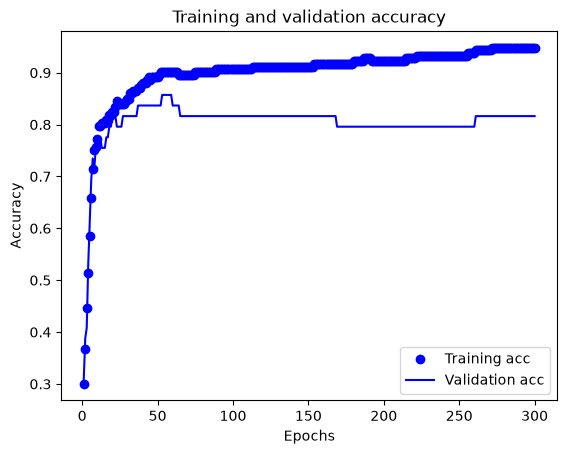

In [92]:
plt.clf()
acc = historyDict["accuracy"]
val_acc = historyDict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [93]:
model.evaluate(np.asarray(testX, dtype=npdType), np.asarray(testY, dtype=npdType))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8197 - loss: 0.4083


[0.4083040654659271, 0.8196721076965332]